# Data Visualization

Slides adapted from https://github.com/iastro-pt/IAPythonCourses/


In [2]:
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Generate dataset for the plots:
from typing import Union 

def create_dataset(dset_size: int) -> Union[np.ndarray, np.ndarray]:
    XX_data = np.random.normal(size=dset_size, 
                            loc=1,
                            scale=10
                            )

    YY_data = np.random.normal(size=dset_size, 
                            loc=1,
                            scale=10
                            )
    return XX_data, YY_data

## Basic plot

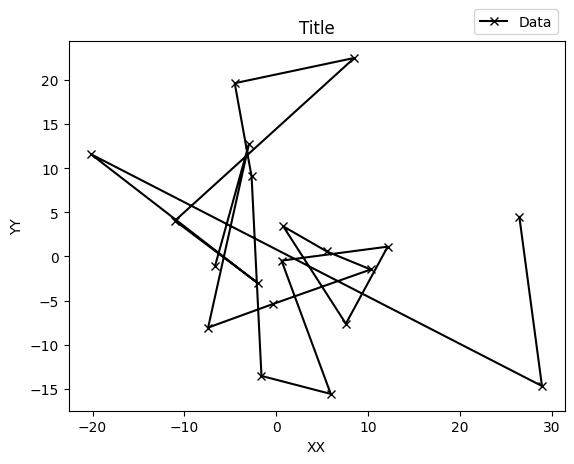

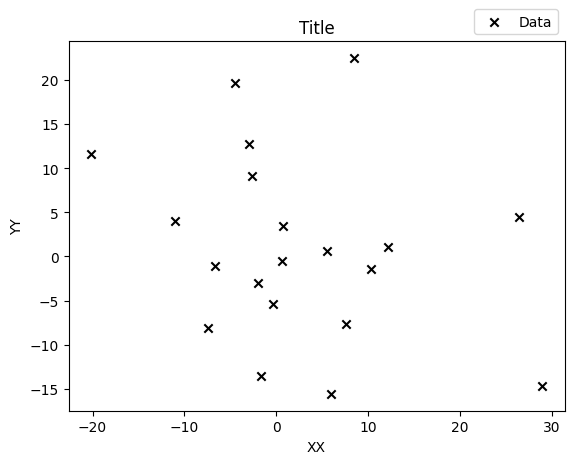

In [4]:
xx, yy = create_dataset(20)

for function in [plt.plot, plt.scatter]:
    plt.figure()
    function(xx, yy, color="black", marker="x", label = "Data")
    plt.xlabel("XX")
    plt.ylabel("YY")
    plt.legend(ncol=1,
            bbox_to_anchor=(1,1),
            loc=4
            )
    plt.title("Title")


## Multiple plots

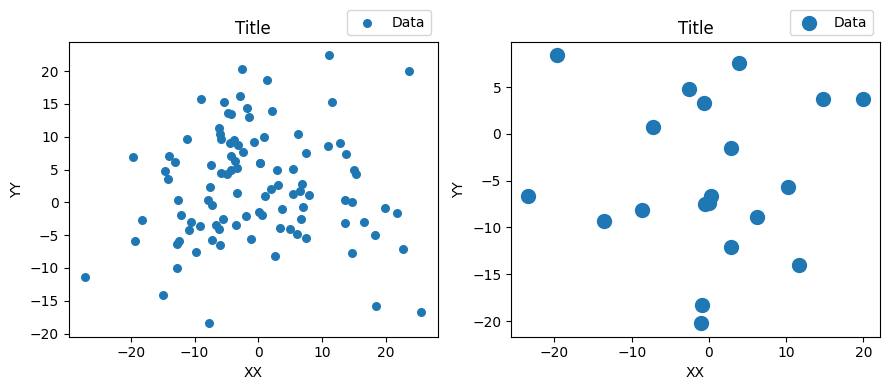

In [5]:

fig, axis = plt.subplots(ncols=2,
                         nrows=1,
                         sharey=False, # False, True, row, col
                         sharex=False, # False, True, row, col
                         figsize=(9, 4),
                         
                         )

for index, size in enumerate([100, 20]):
    ax = axis[index]
    xx, yy = create_dataset(size)
    ax.scatter(xx, yy, s = [30, 100][index], label="Data")
    ax.set_xlabel("XX")
    ax.set_title("Title")
    ax.set_ylabel("YY")
    
    ax.legend(ncol=1,
        bbox_to_anchor=(1,1),
        loc=4
        )

fig.tight_layout()

for fmt in ["pdf", "png"]:
    break # don't want to store them
    fig.savefig(fname=f"teste.{fmt}",
                dpi=600
                )



If there is a need to have more control over the layout of the subplots:

1) https://matplotlib.org/stable/api/_as_gen/matplotlib.gridspec.GridSpec.html
2) https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots_adjust.html


## Histogram

Text(0, 0.5, 'Data')

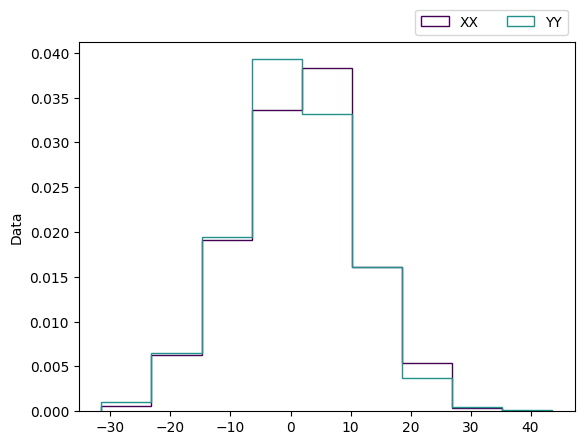

In [6]:
data = create_dataset(1000)

bins = np.linspace(np.min(data),
                   np.max(data),
                   10,
                   )

cmap = plt.get_cmap("viridis") # https://matplotlib.org/stable/users/explain/colors/colormaps.html
norm = plt.Normalize(vmin=0, vmax=len(data))

fig, axis = plt.subplots(1,1)

for index, ind_data in enumerate(data):
    axis.hist(ind_data,
          histtype="step",
          color=cmap(norm(index)),
          label=["XX", "YY"][index],
          density=True,
          bins = bins
          )
    
axis.legend(ncol=2, 
            bbox_to_anchor=(1,1),
            loc=4
            )

axis.set_ylabel("Density")
axis.set_ylabel("Data")

# Plot data with uncertainties

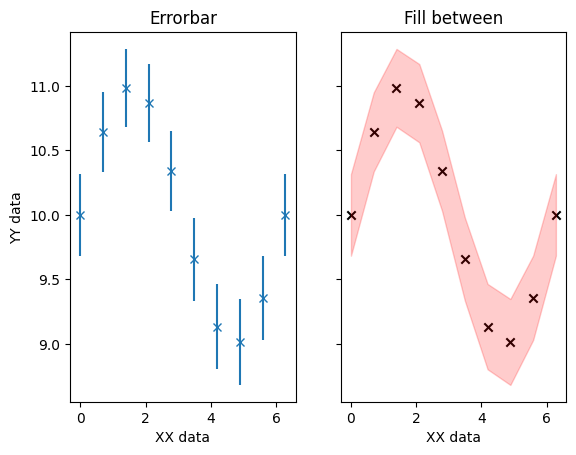

In [7]:
fig, axis = plt.subplots(ncols=2,
                         sharey="row"
                         )

xx_data = np.linspace(0, 2*np.pi, 10)
yy_data = np.sin(xx_data) + 10
sigma = 1/np.sqrt(yy_data)

axis[0].errorbar(xx_data,
                 yy_data, 
                 yerr=sigma,
                 marker='x',
                 ls=""
                 )

axis[1].scatter(xx_data, yy_data, marker='x', color="black")
axis[1].fill_between(xx_data,
                    yy_data - sigma, 
                    yy_data + sigma,
                    color="red",
                    alpha=0.2,
                 )

axis[0].set_ylabel("YY data")
for ax_index, title in enumerate(("Errorbar", "Fill between")):
    axis[ax_index].set_title(title)   
    axis[ax_index].set_xlabel("XX data")

